# PIVA: Diagonal vs. Cholesky Full-Covariance Posterior (with Identifiable v-Latent)

This notebook isolates one question: **does replacing PIVA's diagonal posterior with a full-covariance (Cholesky) posterior, plus an identifiable ILR parameterisation of the volume-fraction latent, actually improve calibrated uncertainty?**

Scope, deliberately narrow: **PIVA-Tight only**, evaluated at a single reference noise level **sigma = 0.05**. NLLS and PIA are kept only as point-accuracy reference rows; they have no posterior, so no coverage concept applies to them.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
# numpy          → numerical simulation and vectorised physics model
# scipy          → curve_fit (the classical NLLS baseline)
# matplotlib     → all plots

import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# b-values (ms/mm²) and TE values (ms) — same as the PIA repo
B_VALS  = [0, 150, 1000, 1500]    # 4 b-values
TE_VALS = [0,  13,   93,  143]    # 4 echo times
N_SIGNALS = len(B_VALS) * len(TE_VALS)  # = 16 signals per voxel

# Flattened b-TE grid: shape (16,) each — used throughout
b_grid  = np.array([[b]*len(TE_VALS) for b in B_VALS], dtype=float).ravel()   # (16,)
te_grid = np.array(TE_VALS * len(B_VALS), dtype=float)                        # (16,)
b_TE_flat = np.vstack([b_grid, te_grid])  # (2, 16) — for scipy curve_fit interface

# Global plot style
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
})
print(f"✓ Imports done  |  Signals per voxel: {N_SIGNALS}  ({len(B_VALS)} b-vals × {len(TE_VALS)} TEs)")


✓ Imports done  |  Signals per voxel: 16  (4 b-vals × 4 TEs)


---
## 1. Data Generation — Biologically Plausible Synthetic Patients


In [2]:
# ── Data generation: patient-level bootstrapped 3-compartment cohort ────────────
# Generates a synthetic prostate MRI cohort with patient-level biological variation.
#
# Data structure:
#   • N_PATIENTS independent patients, each with VOXELS_PER_PATIENT voxels.
#   • Patient-level phenotype drawn from a Dirichlet prior on compartment composition.
#   • Patient-level D/T2 centres are shifted from population means.
#   • Voxel-level D and T2 vary around each patient's own centre.
#   • Clean physics signals computed by pia3_signal_np() (vectorised decoder).
#   • Augmentation applies clinically plausible Rician magnitude noise.

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

COMP_NAMES   = ["epithelium", "stroma", "lumen"]
N_COMP       = 3
SIGNAL_SCALE = 1000.0  # signals are stored at 1000× unit scale

# Rician noise is specified on unit-scale S0. The default range below gives
# S0-level SNR from roughly 100:1 to 12.5:1, avoiding unrealistic 1000+ spikes.
CLINICAL_NOISE_SIGMA_RANGE = (0.01, 0.08)

# Physiological priors matching the original PIA implementation
D_MEAN_3   = np.array([0.5,  1.2,   2.85 ], dtype=np.float32)   # mean D per compartment (×10⁻³ mm²/s)
T2_MEAN_3  = np.array([45.0, 70.0,  750.0 ], dtype=np.float32)   # mean T2 per compartment (ms)
D_DELTA_3  = np.array([0.2,  0.5,   0.15  ], dtype=np.float32)   # half-width for tanh constraint
T2_DELTA_3 = np.array([25.0, 30.0,  250.0 ], dtype=np.float32)   # half-width for tanh constraint

# Physiological bounds implied by the PIA-style mean ± delta parameterisation
D_LOW_3    = D_MEAN_3  - D_DELTA_3
D_HIGH_3   = D_MEAN_3  + D_DELTA_3
T2_LOW_3   = T2_MEAN_3 - T2_DELTA_3
T2_HIGH_3  = T2_MEAN_3 + T2_DELTA_3

# Within-patient voxel spread: smaller than the full physiological range
D_VOXEL_SD_3  = np.array([0.04, 0.12, 0.03], dtype=np.float32)
T2_VOXEL_SD_3 = np.array([6.0,  8.0, 70.0], dtype=np.float32)


def pia3_signal_np(D, T2, v, scale=SIGNAL_SCALE):
    """
    Vectorised 3-compartment MRI signal decoder.

    Computes  S(b, TE) = scale × Σ_c  v_c · exp(−b·D_c/1000) · exp(−TE/T2_c)
    for all (b, TE) pairs in b_grid × te_grid.

    Parameters
    ----------
    D    : (N, 3) float32 — diffusivity per compartment
    T2   : (N, 3) float32 — T2 relaxation time per compartment
    v    : (N, 3) float32 — volume fractions (must sum to 1 per row)
    scale: float          — signal scale factor (default 1000.0)

    Returns
    -------
    S_clean : (N, 16) float32 — clean signals for 4 b-values × 4 echo times
    """
    D  = np.asarray(D,  dtype=np.float32)
    T2 = np.asarray(T2, dtype=np.float32)
    v  = np.asarray(v,  dtype=np.float32)

    b  = b_grid[None,  :, None].astype(np.float32)   # (1, 16, 1)
    te = te_grid[None, :, None].astype(np.float32)   # (1, 16, 1)

    comp_signal = (
        v[:, None, :]                            # volume fraction  (N, 1, 3)
        * np.exp(-b  / 1000.0 * D[:, None, :])  # diffusion decay  (N, 16, 3)
        * np.exp(-te / T2[:, None, :])           # T2 decay         (N, 16, 3)
    )
    return scale * comp_signal.sum(axis=2).astype(np.float32)  # (N, 16)


def generate_pia3_dataset(n, noise_std=0.05, seed=0):
    """Single-patient independent-voxel generator retained for fallback tests."""
    rng = np.random.default_rng(seed)

    D = np.column_stack([
        rng.uniform(0.3, 0.7, n),
        rng.uniform(0.7, 1.7, n),
        rng.uniform(2.7, 3.0, n),
    ]).astype(np.float32)

    T2 = np.column_stack([
        rng.uniform(20,  70,   n),
        rng.uniform(40,  100,  n),
        rng.uniform(500, 1000, n),
    ]).astype(np.float32)

    v_raw = rng.uniform(0, 1, (n, 3)).astype(np.float32)
    v     = v_raw / v_raw.sum(axis=1, keepdims=True)  # simplex projection

    S_clean  = pia3_signal_np(D, T2, v)
    X_noisy  = augment_clean_signals(S_clean, noise_sigma_range=(noise_std, noise_std), seed=seed+10)
    y_params = np.concatenate([D, T2, v], axis=1).astype(np.float32)
    return X_noisy.astype(np.float32), S_clean.astype(np.float32), D, T2, v, y_params


def generate_patient_clean_cohort(n_patients=80, voxels_per_patient=512, seed=0):
    """
    Generate a synthetic prostate MRI cohort with patient-level biological variation.

    Each patient is assigned a Dirichlet-distributed compartment phenotype, which
    biases the volume-fraction distribution of all voxels within that patient.
    Patient-level D/T2 centres are created by shifting the population means;
    voxel-level D/T2 values are then sampled around those patient-specific centres.

    Parameters
    ----------
    n_patients         : int — number of independent synthetic patients
    voxels_per_patient : int — number of voxels sampled per patient
    seed               : int — master RNG seed

    Returns
    -------
    S_clean    : (N, 16)   clean MRI signals at SIGNAL_SCALE
    D          : (N, 3)    diffusivity ground truth
    T2         : (N, 3)    T2 relaxation ground truth
    v          : (N, 3)    volume fraction ground truth
    y_params   : (N, 9)    concatenated [D, T2, v] ground truth
    patient_ids: (N,)      integer patient index per voxel
    patient_meta: DataFrame patient-level metadata
    """
    rng = np.random.default_rng(seed)
    D_all, T2_all, v_all, patient_ids = [], [], [], []
    meta_rows = []

    for pid in range(n_patients):
        n = voxels_per_patient

        # Patient phenotype: Dirichlet prior on compartment composition
        patient_mix = rng.dirichlet(alpha=np.array([1.6, 1.8, 1.6]))
        v_alpha     = 1.0 + 18.0 * patient_mix       # concentration parameter
        v           = rng.dirichlet(v_alpha, size=n).astype(np.float32)

        # Patient-level parameter offsets: one shift per compartment for this patient
        d_shift  = rng.normal(0, [0.025, 0.060, 0.020]).astype(np.float32)
        t2_shift = rng.normal(0, [4.0,   6.0,   55.0 ]).astype(np.float32)

        # First create this patient's D/T2 centres, then sample voxels around them.
        # This avoids drawing a full random physiological range and then shifting it again.
        patient_D_mean  = np.clip(D_MEAN_3  + d_shift,  D_LOW_3,  D_HIGH_3).astype(np.float32)
        patient_T2_mean = np.clip(T2_MEAN_3 + t2_shift, T2_LOW_3, T2_HIGH_3).astype(np.float32)

        D = rng.normal(patient_D_mean, D_VOXEL_SD_3, size=(n, N_COMP)).astype(np.float32)
        D = np.clip(D, D_LOW_3, D_HIGH_3).astype(np.float32)

        T2 = rng.normal(patient_T2_mean, T2_VOXEL_SD_3, size=(n, N_COMP)).astype(np.float32)
        T2 = np.clip(T2, T2_LOW_3, T2_HIGH_3).astype(np.float32)

        D_all.append(D)
        T2_all.append(T2)
        v_all.append(v)
        patient_ids.append(np.full(n, pid, dtype=np.int32))
        meta_rows.append({
            "patient_id": pid,
            "mix_ep": patient_mix[0], "mix_st": patient_mix[1], "mix_lu": patient_mix[2],
            "D_shift_ep": d_shift[0], "D_shift_st": d_shift[1], "D_shift_lu": d_shift[2],
            "T2_shift_ep": t2_shift[0], "T2_shift_st": t2_shift[1], "T2_shift_lu": t2_shift[2],
            "D_mean_ep": patient_D_mean[0], "D_mean_st": patient_D_mean[1], "D_mean_lu": patient_D_mean[2],
            "T2_mean_ep": patient_T2_mean[0], "T2_mean_st": patient_T2_mean[1], "T2_mean_lu": patient_T2_mean[2],
        })

    D  = np.vstack(D_all).astype(np.float32)
    T2 = np.vstack(T2_all).astype(np.float32)
    v  = np.vstack(v_all).astype(np.float32)
    patient_ids  = np.concatenate(patient_ids)
    S_clean      = pia3_signal_np(D, T2, v)
    y_params     = np.concatenate([D, T2, v], axis=1).astype(np.float32)
    patient_meta = pd.DataFrame(meta_rows)
    return S_clean.astype(np.float32), D, T2, v, y_params, patient_ids, patient_meta


def augment_clean_signals(S_clean, noise_sigma_range=CLINICAL_NOISE_SIGMA_RANGE, seed=0):
    """
    Apply Rician magnitude noise to clean MRI signals.

    MRI magnitude images follow a Rician distribution arising from the complex
    Gaussian noise in k-space:

        S_rician = sqrt( (S + ε_real)² + ε_imag² ),   ε ~ N(0, σ²)

    The noise level σ is sampled uniformly from noise_sigma_range per voxel.
    By default σ is relative to unit-scale S0 and spans a clinically plausible
    range rather than an extreme stress-test range.


    Parameters
    ----------
    S_clean           : (N, 16) float32 — clean physics signals at SIGNAL_SCALE
    noise_sigma_range : (lo, hi) — uniform draw range for per-voxel σ on unit-scale S0
    seed              : int — RNG seed for reproducibility

    Returns
    -------
    X_noisy : (N, 16) float32 — Rician-corrupted signals at SIGNAL_SCALE
    """
    rng = np.random.default_rng(seed)
    # Normalise to unit scale so σ is a fraction of peak signal
    S_unit = S_clean.astype(np.float32) / SIGNAL_SCALE   # (N, 16)
    n      = S_unit.shape[0]

    # Draw a per-voxel noise standard deviation on unit-scale S0
    sigma = rng.uniform(noise_sigma_range[0], noise_sigma_range[1], n).astype(np.float32)  # (N,)

    # Complex Gaussian noise: real and imaginary channels, each ~ N(0, σ²)
    e_real = rng.normal(0, 1, S_unit.shape).astype(np.float32) * sigma[:, None]   # (N, 16)
    e_imag = rng.normal(0, 1, S_unit.shape).astype(np.float32) * sigma[:, None]   # (N, 16)

    # Rician magnitude: sqrt( (S + ε_real)² + ε_imag² ), then restore signal scale
    X_noisy = SIGNAL_SCALE * np.sqrt((S_unit + e_real) ** 2 + e_imag ** 2)        # (N, 16)
    return X_noisy.astype(np.float32)


# ── Build training dataset ────────────────────────────────────────────────────
N_PATIENTS         = 80
VOXELS_PER_PATIENT = 512
BOOTSTRAP_PATIENTS = 120
AUGMENT_REPEATS    = 2

# Generate clean base cohort (no noise at this stage)
S_clean_base, D_base3, T2_base3, v_base3, y_base, patient_ids_base, patient_meta = \
    generate_patient_clean_cohort(n_patients=N_PATIENTS, voxels_per_patient=VOXELS_PER_PATIENT, seed=0)

# Bootstrap patients with replacement to increase effective cohort size
rng_boot        = np.random.default_rng(seed=123)
boot_patient_ids = rng_boot.choice(np.arange(N_PATIENTS), size=BOOTSTRAP_PATIENTS, replace=True)
boot_indices     = np.concatenate([np.where(patient_ids_base == pid)[0] for pid in boot_patient_ids])

S_boot        = S_clean_base[boot_indices]
y_boot        = y_base[boot_indices]
D_boot3       = D_base3[boot_indices]
T2_boot3      = T2_base3[boot_indices]
v_boot3       = v_base3[boot_indices]
patient_ids_boot = patient_ids_base[boot_indices]

# Augment each bootstrapped set with clinically plausible Rician noise
# (AUGMENT_REPEATS independent draws from CLINICAL_NOISE_SIGMA_RANGE)
X_parts, S_parts, y_parts, D_parts, T2_parts, v_parts, pid_parts = [], [], [], [], [], [], []
for rep in range(AUGMENT_REPEATS):
    X_parts.append(
        augment_clean_signals(S_boot, noise_sigma_range=CLINICAL_NOISE_SIGMA_RANGE, seed=1000 + rep)
    )
    S_parts.append(S_boot);   y_parts.append(y_boot)
    D_parts.append(D_boot3);  T2_parts.append(T2_boot3)
    v_parts.append(v_boot3);  pid_parts.append(patient_ids_boot)

X_train          = np.vstack(X_parts).astype(np.float32)   # noisy input
S_clean_tr       = np.vstack(S_parts).astype(np.float32)   # clean physics target
y_train          = np.vstack(y_parts).astype(np.float32)   # ground-truth params
D_tr3            = np.vstack(D_parts).astype(np.float32)
T2_tr3           = np.vstack(T2_parts).astype(np.float32)
v_tr3            = np.vstack(v_parts).astype(np.float32)
patient_ids_train = np.concatenate(pid_parts)
N_TRAIN          = X_train.shape[0]

print("✓ Training data ready (clinically plausible Rician noise only)")
print(f"  Base patients          : {N_PATIENTS}")
print(f"  Voxels per patient     : {VOXELS_PER_PATIENT}")
print(f"  Bootstrapped patients  : {BOOTSTRAP_PATIENTS}")
print(f"  Augmentation repeats   : {AUGMENT_REPEATS}")
print(f"  Noise sigma range      : {CLINICAL_NOISE_SIGMA_RANGE} of unit-scale S0")
print(f"  X_train                : {X_train.shape}")
print(f"  S_clean_tr             : {S_clean_tr.shape}")
print(f"  y_train (D,T2,v)       : {y_train.shape}")
print(f"  Volume fractions sum   : [{v_tr3.sum(axis=1).min():.4f}, {v_tr3.sum(axis=1).max():.4f}]")


✓ Training data ready (clinically plausible Rician noise only)
  Base patients          : 80
  Voxels per patient     : 512
  Bootstrapped patients  : 120
  Augmentation repeats   : 2
  Noise sigma range      : (0.01, 0.08) of unit-scale S0
  X_train                : (122880, 16)
  S_clean_tr             : (122880, 16)
  y_train (D,T2,v)       : (122880, 9)
  Volume fractions sum   : [1.0000, 1.0000]


---
## 2. Baseline — NLLS (reference row only, no posterior)


In [3]:
# ── NLLS baseline: held-out cohort, noise sweep, metrics, and helpers ───────
# This cell defines the common evaluation dataset and the baseline NLLS fitter.
# PIA and PIVA reuse the same held-out cohort and same metric helpers later.

SIGMA_TEST_LEVELS = [0.05]   # scope restricted to the single reference clinical noise level
EVAL_SIGMA_REF   = 0.05                        # reference level for scatter plots
NOISE_COLORS     = {0.01: "#70AD47", 0.03: "#5B9BD5", 0.05: "#FFC000", 0.08: "#C0504D"}

N_TEST_PATIENTS         = 24
TEST_VOXELS_PER_PATIENT = 10

# Generate one held-out cohort. All models are tested on this same cohort.
S_clean_test3, D_test3, T2_test3, v_test3, y_test3, patient_ids_test, patient_meta_test = \
    generate_patient_clean_cohort(
        n_patients=N_TEST_PATIENTS,
        voxels_per_patient=TEST_VOXELS_PER_PATIENT,
        seed=999,
    )

N_TEST = S_clean_test3.shape[0]
S_clean_unit_test3 = S_clean_test3 / SIGNAL_SCALE

print(f"Held-out test cohort: {N_TEST_PATIENTS} patients × {TEST_VOXELS_PER_PATIENT} voxels = {N_TEST} voxels")


def add_rician_noise(S_clean_unit, sigma, seed):
    """Add Rician magnitude noise at a fixed unit-scale sigma."""
    rng = np.random.default_rng(seed)
    e_real = rng.normal(0, sigma, S_clean_unit.shape).astype(np.float32)
    e_imag = rng.normal(0, sigma, S_clean_unit.shape).astype(np.float32)
    return SIGNAL_SCALE * np.sqrt((S_clean_unit + e_real) ** 2 + e_imag ** 2).astype(np.float32)


def three_compartment_signal_flat(b_TE, D_ep, D_st, D_lu, T2_ep, T2_st, T2_lu, V_ep, V_st):
    """3-compartment signal model for scipy.curve_fit."""
    b, TE = b_TE
    V_lu = 1.0 - V_ep - V_st
    S_ep = V_ep * np.exp(-b / 1000.0 * D_ep) * np.exp(-TE / T2_ep)
    S_st = V_st * np.exp(-b / 1000.0 * D_st) * np.exp(-TE / T2_st)
    S_lu = V_lu * np.exp(-b / 1000.0 * D_lu) * np.exp(-TE / T2_lu)
    return SIGNAL_SCALE * (S_ep + S_st + S_lu)


def nlls_fit_3comp(signals):
    """Fit 3-compartment parameters voxel-by-voxel with bounded NLLS."""
    D_est  = np.zeros((signals.shape[0], 3), dtype=np.float32)
    T2_est = np.zeros((signals.shape[0], 3), dtype=np.float32)
    v_est  = np.zeros((signals.shape[0], 3), dtype=np.float32)
    valid  = np.ones(signals.shape[0], dtype=bool)

    p0 = [0.55, 1.3, 2.8, 50, 70, 750, 0.3, 0.4]
    lo = [0.3,  0.7, 2.7, 20, 40, 500, 0.0, 0.0]
    hi = [0.7,  1.7, 3.0, 70, 100, 1000, 1.0, 1.0]

    for i in range(signals.shape[0]):
        try:
            coeffs, _ = curve_fit(
                three_compartment_signal_flat,
                b_TE_flat,
                signals[i],
                p0=p0,
                bounds=(lo, hi),
                method="trf",
                maxfev=5000,
            )
        except Exception:
            coeffs = np.array(p0, dtype=float)
            valid[i] = False

        D_est[i]      = coeffs[0:3]
        T2_est[i]     = coeffs[3:6]
        v_est[i, 0:2] = coeffs[6:8]
        v_est[i, 2]   = 1.0 - coeffs[6] - coeffs[7]

    return D_est, T2_est, v_est, valid


def r2_score(true, pred, mask=None):
    """Coefficient of determination across all three compartments jointly."""
    if mask is not None:
        true, pred = true[mask], pred[mask]
    x = true.ravel()
    y = pred.ravel()
    ss_res = np.sum((x - y) ** 2)
    ss_tot = np.sum((x - x.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0.0 else 0.0


def metric_pair(true, pred, mask=None):
    """Return Pearson r and MAE across all compartments jointly."""
    if mask is not None:
        true, pred = true[mask], pred[mask]
    x = true.ravel()
    y = pred.ravel()
    return pearsonr(x, y)[0], float(np.mean(np.abs(x - y)))


def summarize_model_metrics(model_name, D_pred, T2_pred, v_pred, sigma, mask=None):
    """Create one metrics row for a model at one noise level."""
    D_r,  D_mae  = metric_pair(D_test3,  D_pred,  mask)
    T2_r, T2_mae = metric_pair(T2_test3, T2_pred, mask)
    v_r,  v_mae  = metric_pair(v_test3,  v_pred,  mask)

    return {
        "sigma": sigma,
        "model": model_name,
        "D_R2":  r2_score(D_test3,  D_pred,  mask),
        "T2_R2": r2_score(T2_test3, T2_pred, mask),
        "v_R2":  r2_score(v_test3,  v_pred,  mask),
        "D_MAE":  D_mae,
        "T2_MAE": T2_mae,
        "v_MAE":  v_mae,
        "D_r":  D_r,
        "T2_r": T2_r,
        "v_r":  v_r,
    }


def plot_recovery_triplet(model_name, D_pred, T2_pred, v_pred, sigma=EVAL_SIGMA_REF, mask=None):
    """Plot actual vs predicted D, T2, and v for one model at one noise level."""
    if mask is None:
        mask = np.ones(D_test3.shape[0], dtype=bool)

    specs = [
        ("D",  D_test3,  D_pred,  (0.2, 3.3),    "D (×10⁻³ mm²/s)", ".3f"),
        ("T2", T2_test3, T2_pred, (0.0, 1100.0), "T2 (ms)",         ".1f"),
        ("v",  v_test3,  v_pred,  (-0.1, 1.1),   "volume fraction", ".3f"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    color = NOISE_COLORS.get(sigma, "#4472C4")

    for ax, (param_name, true, pred, lims, label, mae_fmt) in zip(axes, specs):
        x = true[mask].ravel()
        y = pred[mask].ravel()
        r2 = r2_score(true, pred, mask)
        _, mae = metric_pair(true, pred, mask)

        ax.scatter(x, y, s=18, alpha=0.45, color=color, edgecolor="none")
        ax.plot(lims, lims, "--", color="#555555", lw=1.3, label="perfect")
        ax.set_xlim(*lims)
        ax.set_ylim(*lims)
        ax.set_xlabel(f"True {param_name}")
        ax.set_ylabel(f"Predicted {param_name}")
        ax.set_title(f"{param_name}: {model_name}", fontweight="bold")
        ax.text(
            0.05, 0.92,
            f"R²={r2:.3f}\nMAE={mae:{mae_fmt}}",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#bbbbbb", alpha=0.9),
        )

    plt.suptitle(f"{model_name}: actual vs predicted parameters at σ={sigma}", fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


# Run NLLS once per test noise level.
plot_results = {}
nlls_rows = []

for seed_offset, sigma in enumerate(SIGMA_TEST_LEVELS):
    X_noisy_test = add_rician_noise(S_clean_unit_test3, sigma, seed=7000 + seed_offset)
    D_nlls, T2_nlls, v_nlls, valid = nlls_fit_3comp(X_noisy_test)

    plot_results[sigma] = {
        "X_noisy": X_noisy_test.astype(np.float32),
        "D_nlls": D_nlls,
        "T2_nlls": T2_nlls,
        "v_nlls": v_nlls,
        "valid": valid,
    }
    nlls_rows.append(summarize_model_metrics("NLLS", D_nlls, T2_nlls, v_nlls, sigma, valid))

nlls_results_df = pd.DataFrame(nlls_rows)
metric_cols = ["sigma", "model", "D_R2", "T2_R2", "v_R2", "D_MAE", "T2_MAE", "v_MAE", "D_r", "T2_r", "v_r"]

print("NLLS baseline metrics")
display(nlls_results_df[metric_cols].round(3))

Held-out test cohort: 24 patients × 10 voxels = 240 voxels
NLLS baseline metrics


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.05,NLLS,0.926,0.807,0.267,0.222,92.712,0.125,0.966,0.919,0.71


---
## 3. PIA — Deterministic Physics-Informed Autoencoder (reference row only)


In [4]:

# ── Build and train Physics-Informed PIA ─────────────────────────
# This follows the physics-informed forward model closely:
#   encode(x) -> D(3), T2(3), v(3)
#   decode(D,T2,v) -> 16 reconstructed signals
#   loss = MSE(reconstructed signal, clean signal)

pia_device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

if pia_device.type == "cuda":
    torch.set_float32_matmul_precision("high")

BATCH_SIZE = 2048 if pia_device.type == "cuda" else 512
NUM_WORKERS = 2 if pia_device.type == "cuda" else 0
print(f"Using device: {pia_device} | batch size: {BATCH_SIZE}")

pia_train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(S_clean_tr),
    torch.from_numpy(y_train),        # monitoring only
)
pia_train_loader = DataLoader(
    pia_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=(pia_device.type == "cuda"),
)




class PIA(nn.Module):
    def __init__(self, number_of_signals=16, hidden_dims=None, predictor_depth=2):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512, 512]

        self.number_of_signals = number_of_signals
        self.number_of_compartments = 3
        self.softmax = nn.Softmax(dim=1)

        # Store physiological constants as model buffers.
        self.register_buffer("D_mean", torch.tensor(D_MEAN_3, dtype=torch.float32))
        self.register_buffer("T2_mean", torch.tensor(T2_MEAN_3, dtype=torch.float32))
        self.register_buffer("D_delta", torch.tensor(D_DELTA_3, dtype=torch.float32))
        self.register_buffer("T2_delta", torch.tensor(T2_DELTA_3, dtype=torch.float32))

        # Shared encoder: 16 MRI signals → deep shared feature representation.
        modules = []
        in_channels = number_of_signals

        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Linear(in_channels, h_dim),
                    nn.LeakyReLU()
                )
            )
            in_channels = h_dim

        self.encoder = nn.Sequential(*modules)

        # Helper function to create each predictor head.
        # Each head has predictor_depth hidden layers, then outputs 3 values.
        def make_predictor(out_dim):
            layers = []

            for _ in range(predictor_depth):
                layers.append(
                    nn.Sequential(
                        nn.Linear(hidden_dims[-1], hidden_dims[-1]),
                        nn.LeakyReLU()
                    )
                )

            layers.append(nn.Linear(hidden_dims[-1], out_dim))
            return nn.Sequential(*layers)

        # Three separate PIA-style heads.
        self.D_predictor = make_predictor(self.number_of_compartments)
        self.T2_predictor = make_predictor(self.number_of_compartments)
        self.v_predictor = make_predictor(self.number_of_compartments)

    def encode(self, x):
        # Pass noisy MRI signal through shared encoder.
        h = self.encoder(x)

        # Predict raw D values, squash with tanh, and map into physiological range.
        D_raw = self.D_predictor(h)
        D = self.D_mean + self.D_delta * torch.tanh(D_raw)

        # Predict raw T2 values, squash with tanh, and map into physiological range.
        T2_raw = self.T2_predictor(h)
        T2 = self.T2_mean + self.T2_delta * torch.tanh(T2_raw)

        # Predict raw volume logits and convert them into fractions summing to 1.
        v_raw = self.v_predictor(h)
        v = self.softmax(v_raw)

        return D, T2, v

    def decode(self, D, T2, v):
        signal = torch.zeros((D.shape[0], self.number_of_signals), device=D.device)

        D, T2, v = D.T, T2.T, v.T

        ctr = 0
        for b in B_VALS:
            for TE in TE_VALS:
                S_ep = v[0] * torch.exp(-b / 1000.0 * D[0]) * torch.exp(-TE / T2[0])
                S_st = v[1] * torch.exp(-b / 1000.0 * D[1]) * torch.exp(-TE / T2[1])
                S_lu = v[2] * torch.exp(-b / 1000.0 * D[2]) * torch.exp(-TE / T2[2])

                signal[:, ctr] = S_ep + S_st + S_lu
                ctr += 1

        return SIGNAL_SCALE * signal

    def forward(self, x):
        # Encode signal into physical tissue parameters.
        D, T2, v = self.encode(x)

        # Decode physical tissue parameters back into MRI signal.
        recon = self.decode(D, T2, v)

        return recon, D, T2, v

    def predict(self, X):
        self.eval()
        x = torch.as_tensor(X, dtype=torch.float32, device=next(self.parameters()).device)
        with torch.no_grad():
            _, D, T2, v = self.forward(x)
        return {
            "D": D.cpu().numpy(),
            "T2": T2.cpu().numpy(),
            "v": v.cpu().numpy(),
        }

# Choose GPU if available, otherwise use CPU.
pia_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pia_encoder = PIA(number_of_signals=N_SIGNALS, predictor_depth=3).to(pia_device)
pia_optimizer = torch.optim.Adam(pia_encoder.parameters(), lr=1e-4)

N_PIA_EPOCHS = 200
pia_history = {"signal_mse": [], "D_mae": [], "T2_mae": [], "v_mae": []}

for epoch in range(1, N_PIA_EPOCHS + 1):
    pia_encoder.train()
    parts = {k: [] for k in pia_history}

    for xb, clean_b, yb in pia_train_loader:
        xb = xb.to(pia_device)
        clean_b = clean_b.to(pia_device)
        yb = yb.to(pia_device)

        pia_optimizer.zero_grad()
        recon, D_hat, T2_hat, v_hat = pia_encoder(xb)
        loss = F.mse_loss(recon, clean_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pia_encoder.parameters(), max_norm=1.0)
        pia_optimizer.step()

        parts["signal_mse"].append(loss.item())
        parts["D_mae"].append(torch.mean(torch.abs(D_hat - yb[:, 0:3])).item())
        parts["T2_mae"].append(torch.mean(torch.abs(T2_hat - yb[:, 3:6])).item())
        parts["v_mae"].append(torch.mean(torch.abs(v_hat - yb[:, 6:9])).item())

    for key in pia_history:
        pia_history[key].append(float(np.mean(parts[key])))

    if epoch == 1 or epoch % 10 == 0 or epoch == N_PIA_EPOCHS:
        print(
            f"Epoch {epoch:03d}/{N_PIA_EPOCHS} | "
            f"signal MSE={pia_history['signal_mse'][-1]:.2f} | "
            f"D MAE={pia_history['D_mae'][-1]:.3f} | "
            f"T2 MAE={pia_history['T2_mae'][-1]:.1f} | "
            f"v MAE={pia_history['v_mae'][-1]:.3f}"
        )

pia_encoder.loss_curve_ = pia_history["signal_mse"]
pia_encoder.n_iter_ = N_PIA_EPOCHS
pia_encoder.loss_ = pia_history["signal_mse"][-1]

print("\n✓ PIA training complete")
print("  encode(x) -> D(3), T2(3), v(3)")
print("  decode(D,T2,v) -> 1000 × sum of ep/st/lu signals")


Using device: cuda | batch size: 2048
Epoch 001/200 | signal MSE=939.19 | D MAE=0.079 | T2 MAE=34.4 | v MAE=0.106
Epoch 010/200 | signal MSE=323.93 | D MAE=0.085 | T2 MAE=33.8 | v MAE=0.084
Epoch 020/200 | signal MSE=306.52 | D MAE=0.089 | T2 MAE=33.7 | v MAE=0.083
Epoch 030/200 | signal MSE=298.11 | D MAE=0.091 | T2 MAE=33.5 | v MAE=0.084
Epoch 040/200 | signal MSE=290.47 | D MAE=0.092 | T2 MAE=33.4 | v MAE=0.084
Epoch 050/200 | signal MSE=282.91 | D MAE=0.091 | T2 MAE=33.4 | v MAE=0.083
Epoch 060/200 | signal MSE=264.67 | D MAE=0.090 | T2 MAE=33.4 | v MAE=0.083
Epoch 070/200 | signal MSE=247.51 | D MAE=0.090 | T2 MAE=33.8 | v MAE=0.083
Epoch 080/200 | signal MSE=229.66 | D MAE=0.089 | T2 MAE=34.1 | v MAE=0.082
Epoch 090/200 | signal MSE=203.05 | D MAE=0.090 | T2 MAE=34.5 | v MAE=0.082
Epoch 100/200 | signal MSE=183.68 | D MAE=0.089 | T2 MAE=34.7 | v MAE=0.082
Epoch 110/200 | signal MSE=168.67 | D MAE=0.089 | T2 MAE=34.9 | v MAE=0.081
Epoch 120/200 | signal MSE=159.15 | D MAE=0.088 | 

In [5]:
# ── Evaluate trained PIA on the same held-out cohort ───────────────────────
pia_rows = []

for sigma in SIGMA_TEST_LEVELS:
    X_noisy_test = plot_results[sigma]["X_noisy"].astype(np.float32)
    pia_pred = pia_encoder.predict(X_noisy_test)

    plot_results[sigma]["D_pia"]  = pia_pred["D"]
    plot_results[sigma]["T2_pia"] = pia_pred["T2"]
    plot_results[sigma]["v_pia"]  = pia_pred["v"]

    pia_rows.append(
        summarize_model_metrics("PIA", pia_pred["D"], pia_pred["T2"], pia_pred["v"], sigma)
    )

pia_results_df = pd.DataFrame(pia_rows)
pia_nlls_results_df = pd.concat([nlls_results_df, pia_results_df], ignore_index=True)

print("PIA metrics")
display(pia_results_df[metric_cols].round(3))

print("PIA vs NLLS")
display(pia_nlls_results_df[metric_cols].sort_values(["sigma", "model"]).round(3))

PIA metrics


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.05,PIA,0.984,0.96,0.593,0.091,35.534,0.093,0.993,0.98,0.777


PIA vs NLLS


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.05,NLLS,0.926,0.807,0.267,0.222,92.712,0.125,0.966,0.919,0.710
1,0.05,PIA,0.984,0.960,0.593,0.091,35.534,0.093,0.993,0.980,0.777


---
## 4. PIVA — Diagonal (baseline) vs. Cholesky Full-Covariance + ILR (today's upgrade)

Both variants share the same encoder, the same physics decoder, the same ELBO training recipe (`signal_MSE + beta * KL`, beta=0.1, 200 epochs, Adam lr=5e-4), and the same `D_delta`/`T2_delta` ('Tight') physiological window. The **only** difference is what the encoder outputs for the approximate posterior over the 9-dimensional latent `z`:

| | Posterior | Latent dim | v-parameterisation |
|---|---|---|---|
| **PIVA-Diagonal** (baseline) | `q(z\|x) = N(mu, diag(sigma^2))` | 9 | 3-dim `softmax(v_raw)` |
| **PIVA-CholeskyILR** (upgrade) | `q(z\|x) = N(mu, L L^T)` | 8 | 2-dim ILR -> `softmax(Psi @ v_raw)` |

The Cholesky change lets the posterior represent correlation between latent dimensions (motivated by a Cramer-Rao/Fisher-information analysis showing strong physical correlation between some compartment parameters, which a diagonal posterior cannot represent by construction). The ILR change removes a structural flaw in the plain 3-dim softmax: `softmax(v_raw + c*1) = softmax(v_raw)` for any constant `c`, so that direction carries zero reconstruction gradient and posterior variance was found to collapse into it (measured separately: that direction held 98.7% of the v-block's variance). ILR removes the redundant direction by construction.

In [6]:
# ── PIVA — Baseline: diagonal-covariance variational posterior ──────────────
#
#   x -> encoder -> (mu, log sigma^2)
#     -> z = mu + sigma * eps,  eps ~ N(0, I)          [reparameterisation]
#     -> params_from_z(z) -> (D, T2, v)
#     -> physics_decoder -> S_hat
#
# KL_diag = -1/2 * sum_j (1 + log(sigma_j^2) - mu_j^2 - sigma_j^2)

class PIVA_Diagonal(nn.Module):
    def __init__(self, n_signals=16, latent_dim=9, hidden_dims=None, predictor_depth=3,
                 D_delta=None, T2_delta=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512, 512]
        modules, in_ch = [], n_signals
        for h in hidden_dims:
            modules.append(nn.Sequential(nn.Linear(in_ch, h), nn.LeakyReLU()))
            in_ch = h
        self.encoder = nn.Sequential(*modules)

        def make_head(out_dim):
            layers = []
            for _ in range(predictor_depth):
                layers.append(nn.Sequential(nn.Linear(hidden_dims[-1], hidden_dims[-1]), nn.LeakyReLU()))
            layers.append(nn.Linear(hidden_dims[-1], out_dim))
            return nn.Sequential(*layers)

        self.fc_mu     = make_head(latent_dim)
        self.fc_logvar = make_head(latent_dim)

        D_dlt  = D_delta  if D_delta  is not None else D_DELTA_3
        T2_dlt = T2_delta if T2_delta is not None else T2_DELTA_3
        self.register_buffer("D_mean",   torch.tensor(D_MEAN_3,  dtype=torch.float32))
        self.register_buffer("T2_mean",  torch.tensor(T2_MEAN_3, dtype=torch.float32))
        self.register_buffer("D_delta",  torch.tensor(D_dlt,     dtype=torch.float32))
        self.register_buffer("T2_delta", torch.tensor(T2_dlt,    dtype=torch.float32))

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(-8.0, 4.0)
        return mu, logvar

    def reparameterize(self, mu, logvar, sample=True):
        if not sample:
            return mu
        eps = torch.randn_like(mu)
        return mu + eps * torch.exp(0.5 * logvar)

    def params_from_z(self, z):
        D_raw, T2_raw, v_raw = z[:, 0:3], z[:, 3:6], z[:, 6:9]
        D  = torch.clamp(self.D_mean  + self.D_delta  * torch.tanh(D_raw),  min=0.01, max=10.0)
        T2 = torch.clamp(self.T2_mean + self.T2_delta * torch.tanh(T2_raw), min=1.0,  max=2000.0)
        v  = F.softmax(v_raw, dim=1)
        return D, T2, v

    def decode(self, D, T2, v):
        return pia_encoder.decode(D, T2, v)

    def forward(self, x, sample=True):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar, sample=sample)
        D, T2, v   = self.params_from_z(z)
        recon      = self.decode(D, T2, v)
        return recon, D, T2, v, mu, logvar


def kl_divergence_diag(mu, logvar):
    """KL[N(mu,diag(sigma^2)) || N(0,I)] = -1/2 * sum_j(1 + log(sigma_j^2) - mu_j^2 - sigma_j^2)"""
    return -0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()


def train_piva(model, loader, kl_fn, n_epochs=200, lr=5e-4, beta=0.1, label="PIVA"):
    """Generic ELBO trainer -- works for both PIVA variants below, since both expose
    forward(x, sample=True) -> (recon, D, T2, v, mu, second_param), and kl_fn(mu, second_param)
    computes the matching KL term (diagonal or full-covariance)."""
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    history = {k: [] for k in ["loss", "signal_mse", "kl", "D_mae", "T2_mae", "v_mae"]}

    for epoch in range(1, n_epochs + 1):
        model.train()
        parts = {k: [] for k in history}
        for xb, clean_b, yb in loader:
            xb, clean_b, yb = xb.to(pia_device), clean_b.to(pia_device), yb.to(pia_device)
            opt.zero_grad()
            recon, D, T2, v, mu, second = model(xb, sample=True)
            sig_mse = F.mse_loss(recon, clean_b)
            kl      = kl_fn(mu, second)
            loss    = sig_mse + beta * kl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            parts["loss"].append(loss.item())
            parts["signal_mse"].append(sig_mse.item())
            parts["kl"].append(kl.item())
            parts["D_mae"].append(torch.mean(torch.abs(D - yb[:, 0:3])).item())
            parts["T2_mae"].append(torch.mean(torch.abs(T2 - yb[:, 3:6])).item())
            parts["v_mae"].append(torch.mean(torch.abs(v - yb[:, 6:9])).item())
        for k in history:
            history[k].append(float(np.mean(parts[k])))
        if epoch == 1 or epoch % 20 == 0 or epoch == n_epochs:
            print(f"{label} | Epoch {epoch:03d}/{n_epochs} | loss={history['loss'][-1]:.2f} | "
                  f"signal_MSE={history['signal_mse'][-1]:.2f} | KL={history['kl'][-1]:.3f} | "
                  f"D_MAE={history['D_mae'][-1]:.3f} | T2_MAE={history['T2_mae'][-1]:.1f} | "
                  f"v_MAE={history['v_mae'][-1]:.3f}")
    return history


In [7]:
# ── PIVA — Upgrade: full-covariance (Cholesky) posterior + identifiable v-latent (ILR) ──
#
#   z = mu + L @ eps,  eps ~ N(0,I),  Sigma = L L^T  (L lower-triangular, 8x8)
#   KL_full = 1/2 * [ sum(L_ij^2) + ||mu||^2 - k - 2*sum(log L_ii) ]
#
# v_raw is now 2-dimensional. clr = Psi @ v_raw (Psi: 3x2 orthonormal, columns sum to 0),
# so clr always sums to zero by construction -- no redundant direction left for the
# softmax that follows: v = softmax(clr).

PSI_ILR = torch.tensor([
    [ 1/np.sqrt(2),  1/np.sqrt(6)],
    [-1/np.sqrt(2),  1/np.sqrt(6)],
    [ 0.0,          -2/np.sqrt(6)],
], dtype=torch.float32)   # (3,2)


class PIVA_CholeskyILR(nn.Module):
    def __init__(self, n_signals=16, hidden_dims=None, predictor_depth=3,
                 D_delta=None, T2_delta=None):
        super().__init__()
        self.latent_dim = 8   # 3 (D) + 3 (T2) + 2 (v via ILR)
        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512, 512]
        modules, in_ch = [], n_signals
        for h in hidden_dims:
            modules.append(nn.Sequential(nn.Linear(in_ch, h), nn.LeakyReLU()))
            in_ch = h
        self.encoder = nn.Sequential(*modules)

        def make_head(out_dim):
            layers = []
            for _ in range(predictor_depth):
                layers.append(nn.Sequential(nn.Linear(hidden_dims[-1], hidden_dims[-1]), nn.LeakyReLU()))
            layers.append(nn.Linear(hidden_dims[-1], out_dim))
            return nn.Sequential(*layers)

        n_tril = self.latent_dim * (self.latent_dim + 1) // 2   # 36 for latent_dim=8
        self.fc_mu    = make_head(self.latent_dim)
        self.fc_L_raw = make_head(n_tril)

        tril_idx  = torch.tril_indices(self.latent_dim, self.latent_dim)
        diag_mask = tril_idx[0] == tril_idx[1]
        self.register_buffer("tril_row", tril_idx[0])
        self.register_buffer("tril_col", tril_idx[1])
        self.register_buffer("diag_mask", diag_mask)

        D_dlt  = D_delta  if D_delta  is not None else D_DELTA_3
        T2_dlt = T2_delta if T2_delta is not None else T2_DELTA_3
        self.register_buffer("D_mean",   torch.tensor(D_MEAN_3,  dtype=torch.float32))
        self.register_buffer("T2_mean",  torch.tensor(T2_MEAN_3, dtype=torch.float32))
        self.register_buffer("D_delta",  torch.tensor(D_dlt,     dtype=torch.float32))
        self.register_buffer("T2_delta", torch.tensor(T2_dlt,    dtype=torch.float32))
        self.register_buffer("Psi", PSI_ILR)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        L_raw = self.fc_L_raw(h)
        B = x.shape[0]
        L = torch.zeros(B, self.latent_dim, self.latent_dim, device=x.device, dtype=x.dtype)
        vals = L_raw.clone()
        vals[:, self.diag_mask] = torch.exp(L_raw[:, self.diag_mask].clamp(-4.0, 2.0))
        L[:, self.tril_row, self.tril_col] = vals
        return mu, L

    def reparameterize(self, mu, L, sample=True):
        if not sample:
            return mu
        eps = torch.randn_like(mu)
        return mu + torch.bmm(L, eps.unsqueeze(-1)).squeeze(-1)

    def params_from_z(self, z):
        D_raw, T2_raw, v_raw2 = z[:, 0:3], z[:, 3:6], z[:, 6:8]
        D  = torch.clamp(self.D_mean  + self.D_delta  * torch.tanh(D_raw),  min=0.01, max=10.0)
        T2 = torch.clamp(self.T2_mean + self.T2_delta * torch.tanh(T2_raw), min=1.0,  max=2000.0)
        clr = v_raw2 @ self.Psi.T
        v = F.softmax(clr, dim=1)
        return D, T2, v

    def decode(self, D, T2, v):
        return pia_encoder.decode(D, T2, v)

    def forward(self, x, sample=True):
        mu, L    = self.encode(x)
        z        = self.reparameterize(mu, L, sample=sample)
        D, T2, v = self.params_from_z(z)
        recon    = self.decode(D, T2, v)
        return recon, D, T2, v, mu, L


def kl_divergence_full(mu, L):
    """KL[N(mu,LL^T) || N(0,I)] = 1/2 * [ sum(L_ij^2) + ||mu||^2 - k - 2*sum(log L_ii) ]"""
    k = mu.shape[1]
    trace_term  = (L ** 2).sum(dim=(1, 2))
    mu_term     = (mu ** 2).sum(dim=1)
    diag_L      = torch.diagonal(L, dim1=1, dim2=2)
    logdet_term = 2.0 * torch.log(diag_L).sum(dim=1)
    kl = 0.5 * (trace_term + mu_term - k - logdet_term)
    return kl.mean()


In [8]:
# ── Train PIVA-Diagonal-Tight (baseline) ──
piva_diag_tight = PIVA_Diagonal(n_signals=N_SIGNALS, latent_dim=9,
                                 D_delta=D_DELTA_3, T2_delta=T2_DELTA_3).to(pia_device)
print("Training PIVA-Diagonal-Tight ...")
hist_diag = train_piva(piva_diag_tight, pia_train_loader, kl_divergence_diag,
                        n_epochs=200, beta=0.1, label="PIVA-Diagonal-Tight")


Training PIVA-Diagonal-Tight ...
PIVA-Diagonal-Tight | Epoch 001/200 | loss=1747.58 | signal_MSE=1744.94 | KL=26.374 | D_MAE=0.098 | T2_MAE=40.6 | v_MAE=0.123
PIVA-Diagonal-Tight | Epoch 020/200 | loss=312.03 | signal_MSE=309.02 | KL=30.075 | D_MAE=0.092 | T2_MAE=35.5 | v_MAE=0.086
PIVA-Diagonal-Tight | Epoch 040/200 | loss=300.16 | signal_MSE=297.19 | KL=29.655 | D_MAE=0.092 | T2_MAE=35.4 | v_MAE=0.086
PIVA-Diagonal-Tight | Epoch 060/200 | loss=272.42 | signal_MSE=269.46 | KL=29.627 | D_MAE=0.089 | T2_MAE=33.7 | v_MAE=0.084
PIVA-Diagonal-Tight | Epoch 080/200 | loss=221.76 | signal_MSE=218.79 | KL=29.651 | D_MAE=0.086 | T2_MAE=32.9 | v_MAE=0.082
PIVA-Diagonal-Tight | Epoch 100/200 | loss=180.94 | signal_MSE=178.00 | KL=29.452 | D_MAE=0.084 | T2_MAE=32.5 | v_MAE=0.079
PIVA-Diagonal-Tight | Epoch 120/200 | loss=146.96 | signal_MSE=144.01 | KL=29.512 | D_MAE=0.083 | T2_MAE=32.3 | v_MAE=0.077
PIVA-Diagonal-Tight | Epoch 140/200 | loss=124.03 | signal_MSE=121.08 | KL=29.479 | D_MAE=0.083 |

In [9]:
# ── Train PIVA-CholeskyILR-Tight (today's upgrade) ──
piva_chol_tight = PIVA_CholeskyILR(n_signals=N_SIGNALS,
                                    D_delta=D_DELTA_3, T2_delta=T2_DELTA_3).to(pia_device)
print("Training PIVA-CholeskyILR-Tight ...")
hist_chol = train_piva(piva_chol_tight, pia_train_loader, kl_divergence_full,
                        n_epochs=200, beta=0.1, label="PIVA-CholeskyILR-Tight")


Training PIVA-CholeskyILR-Tight ...
PIVA-CholeskyILR-Tight | Epoch 001/200 | loss=2257.43 | signal_MSE=2256.23 | KL=11.962 | D_MAE=0.131 | T2_MAE=63.6 | v_MAE=0.162
PIVA-CholeskyILR-Tight | Epoch 020/200 | loss=313.31 | signal_MSE=311.29 | KL=20.168 | D_MAE=0.099 | T2_MAE=41.2 | v_MAE=0.087
PIVA-CholeskyILR-Tight | Epoch 040/200 | loss=298.00 | signal_MSE=295.98 | KL=20.211 | D_MAE=0.094 | T2_MAE=41.7 | v_MAE=0.086
PIVA-CholeskyILR-Tight | Epoch 060/200 | loss=253.11 | signal_MSE=251.05 | KL=20.565 | D_MAE=0.087 | T2_MAE=40.5 | v_MAE=0.084
PIVA-CholeskyILR-Tight | Epoch 080/200 | loss=192.70 | signal_MSE=190.63 | KL=20.694 | D_MAE=0.083 | T2_MAE=39.9 | v_MAE=0.080
PIVA-CholeskyILR-Tight | Epoch 100/200 | loss=154.64 | signal_MSE=152.56 | KL=20.866 | D_MAE=0.082 | T2_MAE=39.4 | v_MAE=0.078
PIVA-CholeskyILR-Tight | Epoch 120/200 | loss=130.92 | signal_MSE=128.83 | KL=20.894 | D_MAE=0.082 | T2_MAE=39.5 | v_MAE=0.075
PIVA-CholeskyILR-Tight | Epoch 140/200 | loss=104.08 | signal_MSE=101.95 

---
## 5. Point Accuracy and RAW (uncalibrated) Coverage, sigma=0.05


In [10]:
def mc_predict_piva(model, X, n_mc=25):
    """Monte Carlo posterior mean/sd -- works for either PIVA variant unchanged,
    since both expose forward(x, sample=True) returning (recon, D, T2, v, mu, second)."""
    x = torch.as_tensor(X, dtype=torch.float32, device=pia_device)
    D_s, T2_s, v_s = [], [], []
    model.eval()
    with torch.no_grad():
        for _ in range(n_mc):
            _, D, T2, v, _, _ = model(x, sample=True)
            D_s.append(D.cpu().numpy()); T2_s.append(T2.cpu().numpy()); v_s.append(v.cpu().numpy())
    D_s, T2_s, v_s = np.stack(D_s), np.stack(T2_s), np.stack(v_s)
    return {"D": D_s.mean(0), "T2": T2_s.mean(0), "v": v_s.mean(0),
            "D_sd": D_s.std(0), "T2_sd": T2_s.std(0), "v_sd": v_s.std(0)}

def coverage_95(true, mean, sd):
    lo, hi = mean - 1.96 * sd, mean + 1.96 * sd
    return float(((true >= lo) & (true <= hi)).mean())

X_eval = plot_results[EVAL_SIGMA_REF]["X_noisy"].astype(np.float32)
pred_diag = mc_predict_piva(piva_diag_tight, X_eval, n_mc=25)
pred_chol = mc_predict_piva(piva_chol_tight, X_eval, n_mc=25)

piva_rows = []
for name, pred in [("PIVA-Diagonal", pred_diag), ("PIVA-CholeskyILR", pred_chol)]:
    row = summarize_model_metrics(name, pred["D"], pred["T2"], pred["v"], EVAL_SIGMA_REF)
    row["D_sd"], row["T2_sd"], row["v_sd"] = pred["D_sd"].mean(), pred["T2_sd"].mean(), pred["v_sd"].mean()
    piva_rows.append(row)
piva_results_df = pd.DataFrame(piva_rows)

all_results_df = pd.concat([nlls_results_df, pia_results_df, piva_results_df], ignore_index=True)
print(f"── Accuracy, all models, sigma={EVAL_SIGMA_REF} ──")
display(all_results_df[metric_cols].round(3))

param_names = ["D_ep","D_st","D_lum","T2_ep","T2_st","T2_lum","v_ep","v_st","v_lum"]
raw_cov_rows = []
for name, pred in [("PIVA-Diagonal", pred_diag), ("PIVA-CholeskyILR", pred_chol)]:
    y_true = np.concatenate([D_test3, T2_test3, v_test3], axis=1)
    y_mean = np.concatenate([pred["D"], pred["T2"], pred["v"]], axis=1)
    y_sd   = np.concatenate([pred["D_sd"], pred["T2_sd"], pred["v_sd"]], axis=1)
    for j, pname in enumerate(param_names):
        raw_cov_rows.append({"model": name, "param": pname,
                              "coverage_95": coverage_95(y_true[:, j], y_mean[:, j], y_sd[:, j]),
                              "sd_mean": float(y_sd[:, j].mean())})
raw_cov_df = pd.DataFrame(raw_cov_rows)
raw_cov_pivot = raw_cov_df.pivot(index="param", columns="model", values="coverage_95").loc[param_names]
print(f"\n── RAW 95% CI coverage per compartment, target 0.950 ──")
display(raw_cov_pivot.round(3))


── Accuracy, all models, sigma=0.05 ──


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.05,NLLS,0.926,0.807,0.267,0.222,92.712,0.125,0.966,0.919,0.710
1,0.05,PIA,0.984,0.960,0.593,0.091,35.534,0.093,0.993,0.980,0.777
2,0.05,PIVA-Diagonal,0.987,0.966,0.577,0.080,33.525,0.097,0.994,0.987,0.759
3,0.05,PIVA-CholeskyILR,0.988,0.957,0.568,0.077,37.295,0.097,0.994,0.984,0.754



── RAW 95% CI coverage per compartment, target 0.950 ──


model,PIVA-CholeskyILR,PIVA-Diagonal
param,,
D_ep,0.367,0.096
D_st,0.158,0.071
D_lum,0.629,0.346
T2_ep,0.200,0.088
T2_st,0.142,0.050
T2_lum,0.546,0.179
v_ep,0.121,0.025
v_st,0.092,0.021
v_lum,0.142,0.092


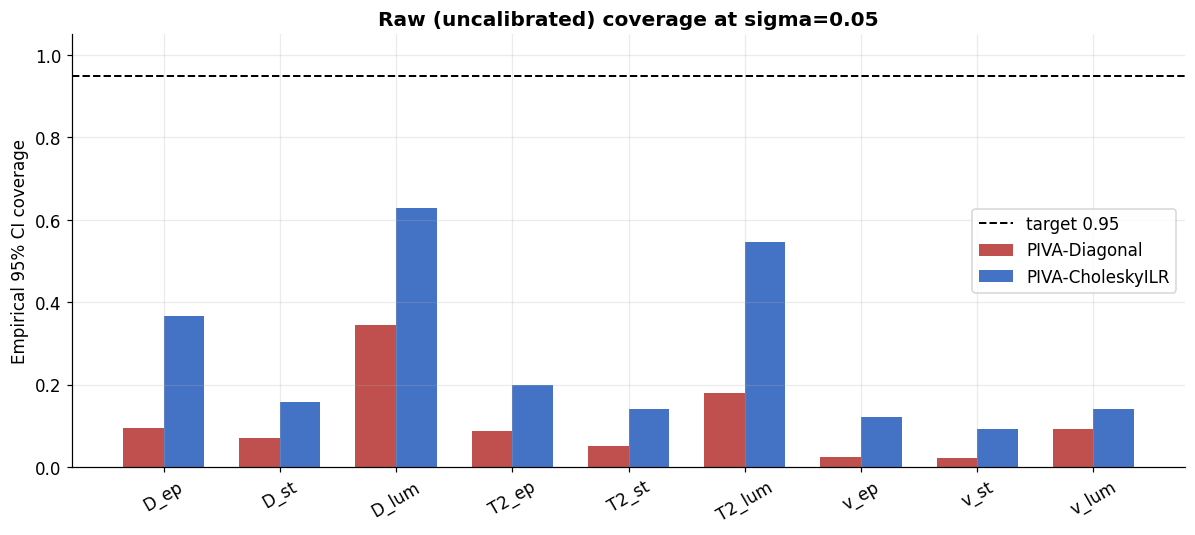

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(param_names)); width = 0.35
ax.bar(x - width/2, raw_cov_pivot["PIVA-Diagonal"], width, label="PIVA-Diagonal", color="#C0504D")
ax.bar(x + width/2, raw_cov_pivot["PIVA-CholeskyILR"], width, label="PIVA-CholeskyILR", color="#4472C4")
ax.axhline(0.95, color="k", ls="--", lw=1.3, label="target 0.95")
ax.set_xticks(x); ax.set_xticklabels(param_names, rotation=30)
ax.set_ylabel("Empirical 95% CI coverage"); ax.set_ylim(0, 1.05)
ax.set_title(f"Raw (uncalibrated) coverage at sigma={EVAL_SIGMA_REF}", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()


---
## 6. Per-Compartment Calibration

Raw coverage above is not the practically usable number -- it needs post-hoc calibration regardless of architecture. A single scalar temperature `tau` per compartment is fit on a held-out calibration split to hit 95% coverage, then applied to a separate held-out test split. This is a no-gradient, frozen-weight step -- true labels are used here only for calibration and evaluation, never inside a training loss.

In [12]:
def calibrate_model(y_true, y_mean, y_sd, param_names, target=0.95, seed=0):
    N = y_true.shape[0]
    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)
    calib_idx, test_idx = perm[:N // 2], perm[N // 2:]
    tau_grid = np.linspace(0.5, 25.0, 500)

    def cov(true, mean, sd, tau):
        lo, hi = mean - 1.96 * tau * sd, mean + 1.96 * tau * sd
        return float(((true >= lo) & (true <= hi)).mean())

    rows = []
    for j, name in enumerate(param_names):
        covs = [cov(y_true[calib_idx, j], y_mean[calib_idx, j], y_sd[calib_idx, j], t) for t in tau_grid]
        tau  = tau_grid[int(np.argmin(np.abs(np.array(covs) - target)))]
        test_cov  = cov(y_true[test_idx, j], y_mean[test_idx, j], y_sd[test_idx, j], tau)
        cal_width = float(2 * 1.96 * tau * y_sd[test_idx, j].mean())
        raw_width = float(2 * 1.96 * y_sd[test_idx, j].mean())
        rows.append({"param": name, "tau": tau, "test_coverage": test_cov,
                     "raw_width": raw_width, "calibrated_width": cal_width})
    return pd.DataFrame(rows).set_index("param")

calib_results = {}
for name, pred in [("PIVA-Diagonal", pred_diag), ("PIVA-CholeskyILR", pred_chol)]:
    y_true = np.concatenate([D_test3, T2_test3, v_test3], axis=1)
    y_mean = np.concatenate([pred["D"], pred["T2"], pred["v"]], axis=1)
    y_sd   = np.concatenate([pred["D_sd"], pred["T2_sd"], pred["v_sd"]], axis=1)
    calib_results[name] = calibrate_model(y_true, y_mean, y_sd, param_names)
    print(f"── Calibrated, {name}, sigma={EVAL_SIGMA_REF} ──")
    display(calib_results[name].round(4))


── Calibrated, PIVA-Diagonal, sigma=0.05 ──


,tau,test_coverage,raw_width,calibrated_width
param,,,,
D_ep,24.2635,0.9083,0.0128,0.3117
D_st,24.9509,0.9583,0.0319,0.7968
D_lum,5.3116,0.9833,0.0624,0.3317
T2_ep,18.6172,0.9083,1.6680,31.0526
T2_st,24.4599,0.8333,1.8808,46.0047
T2_lum,13.8547,0.9083,43.2654,599.4297
v_ep,24.7545,0.9167,0.0169,0.4177
v_st,24.3126,0.8417,0.0198,0.4823
v_lum,16.9479,0.9000,0.0166,0.2806


── Calibrated, PIVA-CholeskyILR, sigma=0.05 ──


,tau,test_coverage,raw_width,calibrated_width
param,,,,
D_ep,5.6062,0.9583,0.0632,0.3542
D_st,11.3998,0.9667,0.0743,0.8466
D_lum,2.0220,0.9500,0.1039,0.2102
T2_ep,7.4719,0.9083,3.7288,27.8611
T2_st,14.4930,0.9500,4.2875,62.1392
T2_lum,3.3477,0.9250,168.4495,563.9176
v_ep,13.1182,0.9250,0.0384,0.5035
v_st,11.5962,0.9500,0.0556,0.6442
v_lum,10.1723,0.9250,0.0280,0.2846


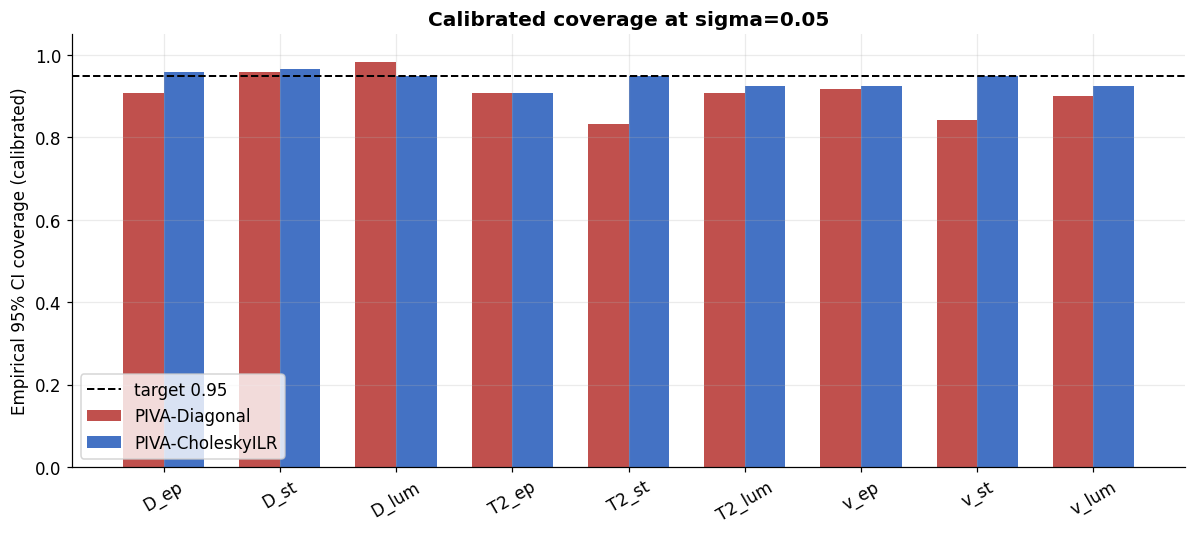

── Calibrated interval width as % of each parameter's physiological range ──


model,PIVA-CholeskyILR,PIVA-Diagonal
param,,
D_ep,88.6,77.9
D_st,84.7,79.7
D_lum,70.1,110.6
T2_ep,55.7,62.1
T2_st,103.6,76.7
T2_lum,112.8,119.9
v_ep,50.4,41.8
v_st,64.4,48.2
v_lum,28.5,28.1


In [13]:
cal_cov_pivot = pd.DataFrame({name: calib_results[name]["test_coverage"] for name in calib_results}).loc[param_names]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(param_names)); width = 0.35
ax.bar(x - width/2, cal_cov_pivot["PIVA-Diagonal"], width, label="PIVA-Diagonal", color="#C0504D")
ax.bar(x + width/2, cal_cov_pivot["PIVA-CholeskyILR"], width, label="PIVA-CholeskyILR", color="#4472C4")
ax.axhline(0.95, color="k", ls="--", lw=1.3, label="target 0.95")
ax.set_xticks(x); ax.set_xticklabels(param_names, rotation=30)
ax.set_ylabel("Empirical 95% CI coverage (calibrated)"); ax.set_ylim(0, 1.05)
ax.set_title(f"Calibrated coverage at sigma={EVAL_SIGMA_REF}", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

full_range = {}
for i, k in enumerate(["D_ep", "D_st", "D_lum"]):   full_range[k] = 2 * D_DELTA_3[i]
for i, k in enumerate(["T2_ep", "T2_st", "T2_lum"]): full_range[k] = 2 * T2_DELTA_3[i]
for k in ["v_ep", "v_st", "v_lum"]: full_range[k] = 1.0

width_rows = []
for name in calib_results:
    for pname in param_names:
        w = calib_results[name].loc[pname, "calibrated_width"]
        width_rows.append({"model": name, "param": pname, "calibrated_width": w,
                            "pct_of_range": 100 * w / full_range[pname]})
width_df = pd.DataFrame(width_rows)
width_pivot = width_df.pivot(index="param", columns="model", values="pct_of_range").loc[param_names]
print("── Calibrated interval width as % of each parameter's physiological range ──")
display(width_pivot.round(1))


---
## 7. Verdict

Computed directly from the tables above -- nothing here is asserted in advance.

In [14]:
print("=" * 78)
print(f"VERDICT: PIVA-Diagonal vs PIVA-CholeskyILR, sigma={EVAL_SIGMA_REF}")
print("=" * 78)

raw_delta = (raw_cov_pivot["PIVA-CholeskyILR"] - raw_cov_pivot["PIVA-Diagonal"]) * 100
print("\nRaw coverage change (CholeskyILR - Diagonal), percentage points:")
display(raw_delta.round(1))

cal_delta = (cal_cov_pivot["PIVA-CholeskyILR"] - cal_cov_pivot["PIVA-Diagonal"]) * 100
print("\nCalibrated coverage change (CholeskyILR - Diagonal), percentage points:")
display(cal_delta.round(1))

print("\nCalibrated width, % of physiological range (lower = sharper / more clinically useful):")
display(width_pivot.round(1))

print("\nInterpretation:")
print(f"- Compartments where raw coverage improved      : {list(raw_delta[raw_delta > 0].index)}")
print(f"- Compartments where raw coverage got worse      : {list(raw_delta[raw_delta < 0].index)}")
print(f"- Compartments where calibrated coverage improved: {list(cal_delta[cal_delta > 0].index)}")
worst = width_pivot[(width_pivot["PIVA-Diagonal"] > 90) | (width_pivot["PIVA-CholeskyILR"] > 90)]
print(f"- Compartments where calibrated width still exceeds 90% of the physiological range")
print(f"  (technically calibrated, but barely informative): {list(worst.index)}")


VERDICT: PIVA-Diagonal vs PIVA-CholeskyILR, sigma=0.05

Raw coverage change (CholeskyILR - Diagonal), percentage points:


,0
param,
D_ep,27.1
D_st,8.8
D_lum,28.3
T2_ep,11.3
T2_st,9.2
T2_lum,36.7
v_ep,9.6
v_st,7.1
v_lum,5.0



Calibrated coverage change (CholeskyILR - Diagonal), percentage points:


,0
param,
D_ep,5.0
D_st,0.8
D_lum,-3.3
T2_ep,0.0
T2_st,11.7
T2_lum,1.7
v_ep,0.8
v_st,10.8
v_lum,2.5



Calibrated width, % of physiological range (lower = sharper / more clinically useful):


model,PIVA-CholeskyILR,PIVA-Diagonal
param,,
D_ep,88.6,77.9
D_st,84.7,79.7
D_lum,70.1,110.6
T2_ep,55.7,62.1
T2_st,103.6,76.7
T2_lum,112.8,119.9
v_ep,50.4,41.8
v_st,64.4,48.2
v_lum,28.5,28.1



Interpretation:
- Compartments where raw coverage improved      : ['D_ep', 'D_st', 'D_lum', 'T2_ep', 'T2_st', 'T2_lum', 'v_ep', 'v_st', 'v_lum']
- Compartments where raw coverage got worse      : []
- Compartments where calibrated coverage improved: ['D_ep', 'D_st', 'T2_st', 'T2_lum', 'v_ep', 'v_st', 'v_lum']
- Compartments where calibrated width still exceeds 90% of the physiological range
  (technically calibrated, but barely informative): ['D_lum', 'T2_st', 'T2_lum']
